# Text Summarization with Transformers — Phase 2: Fine-Tuning BART

## Project Overview

This is the second phase of the summarization project. Phase 1 built an
Encoder-Decoder Transformer from scratch and established a baseline
(ROUGE-1 ≈ 0.20). This notebook fine-tunes a pretrained model — **BART-base** —
on the same task, to measure how much pretraining improves results.

## Approach

Instead of learning language and summarization from zero, BART already understands
grammar and semantics from large-scale pretraining. Fine-tuning only adapts that
existing knowledge to the summarization task, which is a much easier problem than
training from scratch.

## Expected Outcome

ROUGE scores here are expected to be substantially higher than Phase 1
(roughly ROUGE-1 0.35–0.42 vs. ~0.20). This gap is the core result of the project.

In [1]:
import numpy as np
import pandas as pd
import torch
from transformers import (
    BartForConditionalGeneration,
    BartTokenizerFast,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset as HFDataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### Loading the CNN/DailyMail data 

In [2]:
import glob

candidates = glob.glob("/kaggle/input/**/train.csv", recursive=True)
train_path = candidates[0]
base_dir = train_path.rsplit("/", 1)[0]

train_df_full = pd.read_csv(f"{base_dir}/train.csv")
val_df_full = pd.read_csv(f"{base_dir}/validation.csv")

N_TRAIN_FT = 20000
N_VAL_FT = 1000

train_df = train_df_full.sample(n=N_TRAIN_FT, random_state=42).reset_index(drop=True)
val_df = val_df_full.sample(n=N_VAL_FT, random_state=42).reset_index(drop=True)

train_hf = HFDataset.from_pandas(train_df[["article", "highlights"]])
val_hf = HFDataset.from_pandas(val_df[["article", "highlights"]])

### Tokenization with BART's own tokenizer

In [3]:
# Load BART tokenizer and model
MODEL_NAME = "facebook/bart-base"

tokenizer = BartTokenizerFast.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

MAX_SRC_LEN = 512
MAX_TGT_LEN = 96

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

In [4]:
# Tokenize the dataset
def preprocess(batch):
    model_inputs = tokenizer(
        batch["article"], max_length=MAX_SRC_LEN, truncation=True
    )
    labels = tokenizer(
        text_target=batch["highlights"], max_length=MAX_TGT_LEN, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tok = train_hf.map(preprocess, batched=True, remove_columns=["article", "highlights"])
val_tok = val_hf.map(preprocess, batched=True, remove_columns=["article", "highlights"])

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
# ROUGE metric for evaluation during training
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}
    for pred, ref in zip(decoded_preds, decoded_labels):
        result = scorer.score(ref, pred)
        for key in scores:
            scores[key].append(result[key].fmeasure)

    return {k: np.mean(v) for k, v in scores.items()}

### Fine-tuning facebook/bart-base using Hugging Face's Seq2SeqTrainer

In [6]:
# Training arguments and Trainer
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bart_summarizer",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    num_train_epochs=3,
    predict_with_generate=True,
    generation_max_length=MAX_TGT_LEN,
    fp16=True,
    logging_steps=50,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [7]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,4.370154,1.832061,0.429086,0.198920,0.294052
2,4.175506,1.806686,0.427660,0.200543,0.295750
3,3.993935,1.794294,0.427254,0.198463,0.295179


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3750, training_loss=4.237065104166667, metrics={'train_runtime': 3872.795, 'train_samples_per_second': 15.493, 'train_steps_per_second': 0.968, 'total_flos': 1.82920937472e+16, 'train_loss': 4.237065104166667, 'epoch': 3.0})

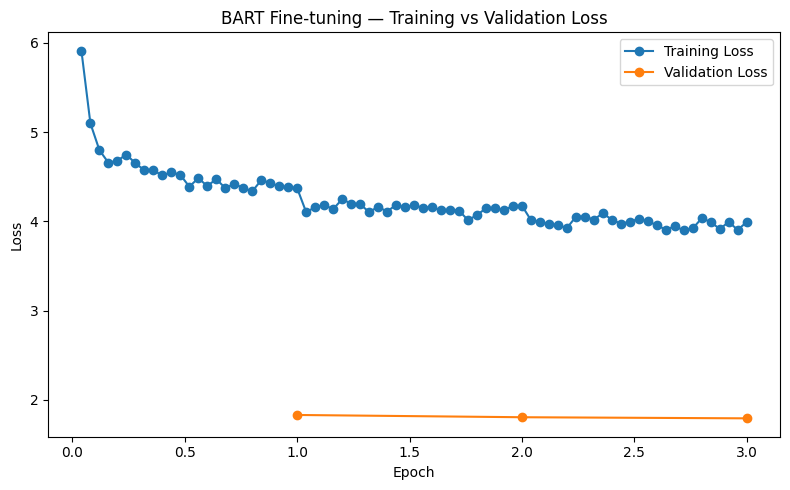

In [8]:
log_history = trainer.state.log_history

train_epochs, train_losses = [], []
eval_epochs, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")
plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BART Fine-tuning — Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("bart_loss_curve.png", dpi=150)
plt.show()

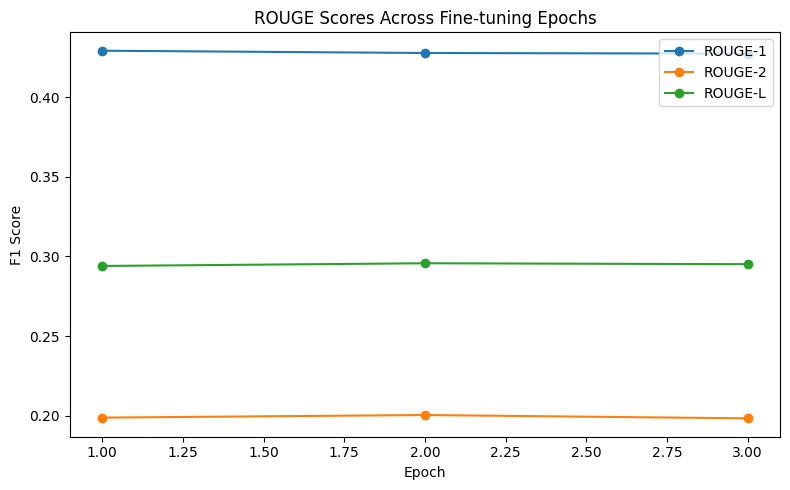

In [9]:
eval_rouge1, eval_rouge2, eval_rougeL = [], [], []

for entry in log_history:
    if "eval_rouge1" in entry:
        eval_rouge1.append(entry["eval_rouge1"])
        eval_rouge2.append(entry["eval_rouge2"])
        eval_rougeL.append(entry["eval_rougeL"])

epochs_range = list(range(1, len(eval_rouge1) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, eval_rouge1, marker="o", label="ROUGE-1")
plt.plot(epochs_range, eval_rouge2, marker="o", label="ROUGE-2")
plt.plot(epochs_range, eval_rougeL, marker="o", label="ROUGE-L")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("ROUGE Scores Across Fine-tuning Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("bart_rouge_progression.png", dpi=150)
plt.show()

### Side-by-side comparison against the Phase 1 baseline

In [10]:
#  Compare against Phase 1 baseline
sample_article = val_df.iloc[0]["article"]
sample_reference = val_df.iloc[0]["highlights"]

inputs = tokenizer(sample_article, max_length=MAX_SRC_LEN, truncation=True, return_tensors="pt").to(device)
summary_ids = model.generate(inputs["input_ids"], max_length=MAX_TGT_LEN, num_beams=4)
generated = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("REFERENCE:\n", sample_reference)
print("\nGENERATED (BART fine-tuned):\n", generated)

final_metrics = trainer.evaluate()
print(final_metrics)

REFERENCE:
 Was last spotted in Burma in 1941,and was thought to have died out .
Scientists used a recording of its distinctive call to rediscover species .
Discovery proves bird and habitat both still exist in Myanmar .

GENERATED (BART fine-tuned):
 Jerdon's Babbler was last spotted in Myanmar in 1941 and was thought to have died out altogether .
But a team of scientists managed to uncover multiple birds nesting in a small area of grassland in Myanmar's central Bago region in May last year .
The scientists used a recording of the species' distinctive call to track it down .
They then used the recording to see if the bird would show itself .


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.7942936420440674, 'eval_rouge1': 0.42725368746022435, 'eval_rouge2': 0.1984628830414486, 'eval_rougeL': 0.29517867696642147, 'eval_runtime': 311.7631, 'eval_samples_per_second': 3.208, 'eval_steps_per_second': 0.202, 'epoch': 3.0}


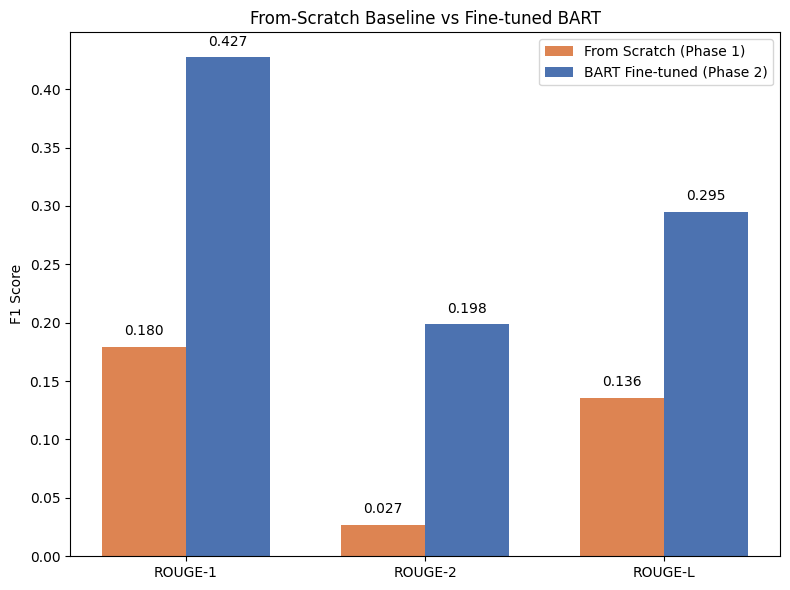

In [11]:
metrics_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
scratch_scores = [0.1796, 0.0268, 0.1359]   # Phase 1
bart_scores = [final_metrics["eval_rouge1"], final_metrics["eval_rouge2"], final_metrics["eval_rougeL"]]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, scratch_scores, width, label="From Scratch (Phase 1)", color="#DD8452")
plt.bar(x + width/2, bart_scores, width, label="BART Fine-tuned (Phase 2)", color="#4C72B0")

plt.xticks(x, metrics_names)
plt.ylabel("F1 Score")
plt.title("From-Scratch Baseline vs Fine-tuned BART")
plt.legend()

for i, (s, b) in enumerate(zip(scratch_scores, bart_scores)):
    plt.text(i - width/2, s + 0.01, f"{s:.3f}", ha="center")
    plt.text(i + width/2, b + 0.01, f"{b:.3f}", ha="center")

plt.tight_layout()
plt.savefig("baseline_vs_finetuned.png", dpi=150)
plt.show()

In [12]:
import pandas as pd
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

sample_results = []
for i in range(5):
    article = val_df.iloc[i]["article"]
    reference = val_df.iloc[i]["highlights"]

    inputs = tokenizer(article, max_length=MAX_SRC_LEN, truncation=True, return_tensors="pt").to(device)
    summary_ids = model.generate(inputs["input_ids"], max_length=MAX_TGT_LEN, num_beams=4)
    generated = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    r1 = scorer.score(reference, generated)["rouge1"].fmeasure
    sample_results.append({
        "Reference": reference[:100] + "...",
        "Generated": generated[:100] + "...",
        "ROUGE-1": round(r1, 3)
    })

results_df = pd.DataFrame(sample_results)
results_df

,Reference,Generated,ROUGE-1
0,"Was last spotted in Burma in 1941,and was thou...",Jerdon's Babbler was last spotted in Myanmar i...,0.467
1,Pastor Mal Feebrey discovered he had terminal ...,"Mal Feebrey, a men's mental health ambassador,...",0.463
2,Everton take on Dynamo Kiev in the Europa Leag...,Roberto Martinez has expressed concerns over t...,0.345
3,Hospitals still failing to claw back the cost ...,The so-called ‘health tourism gap’ between the...,0.634
4,North Carolina State University has disbanded ...,University Chancellor Randy Woodson announced ...,0.351
